In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ─── Step 1: Load and Clean ───────────────────────────────────
df_train = pd.read_csv("Train.csv")
df_test = pd.read_csv("Test.csv")

In [3]:
education_map = {
    "Preschool": 1, "1st-4th": 2, "5th-6th": 3, "7th-8th": 4,
    "9th": 5, "10th": 6, "11th": 7, "12th": 8, "HS-grad": 9,
    "Some-college": 10, "Assoc-voc": 11, "Assoc-acdm": 12,
    "Bachelors": 13, "Masters": 14, "Prof-school": 15, "Doctorate": 16
}

In [5]:
# Standardize column names
df_test = df_test.rename(columns={
    "workclass": "work-class",
    "fnlwgt":    "work-fnl",
    "occupation":"position"
})

In [7]:
# Remove duplicates
df_train = df_train.drop_duplicates()
df_test  = df_test.drop_duplicates()

In [9]:
# Handle hidden nulls (' ?') then strip ALL string columns
df_train.replace(" ?", np.nan, inplace=True)
df_test.replace(" ?", np.nan, inplace=True)
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

✅ Strip leading/trailing spaces from every string column

In [11]:
for col in df_train.select_dtypes(include='object').columns:
    df_train[col] = df_train[col].str.strip()
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].str.strip()

C:\Users\abdel\AppData\Local\Temp\ipykernel_2120\2040362201.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_train.select_dtypes(include='object').columns:
C:\Users\abdel\AppData\Local\Temp\ipykernel_2120\2040362201.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

In [13]:
# Encode target
target = "salary"
le = LabelEncoder()
df_train["salary"] = le.fit_transform(df_train["salary"])
df_test["salary"]  = le.transform(df_test["salary"])

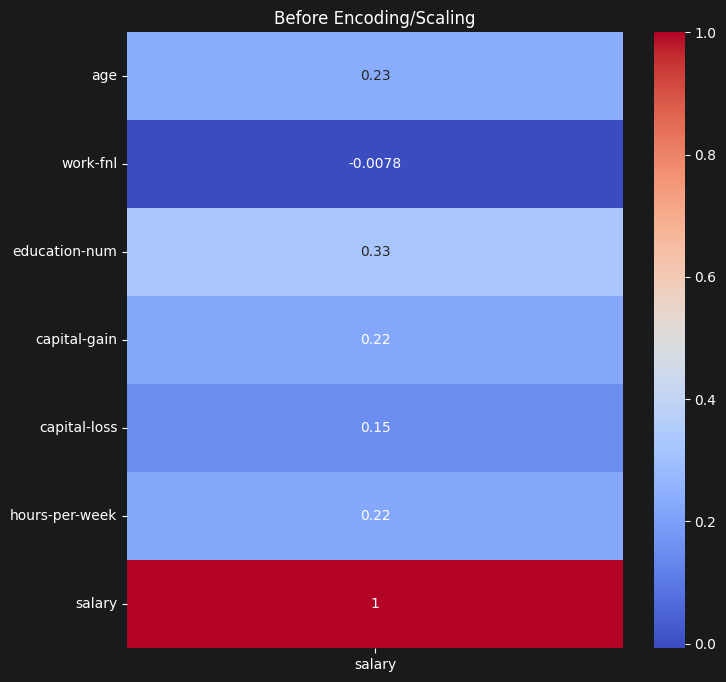

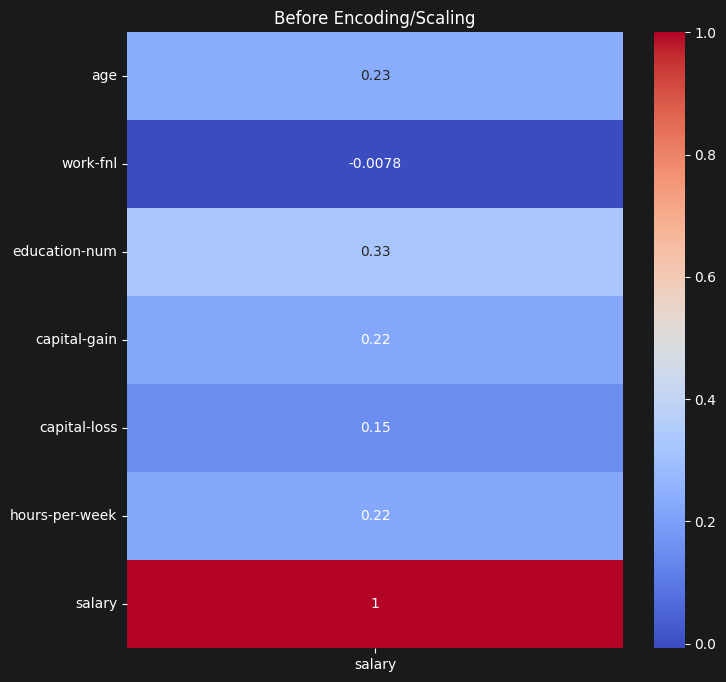

In [15]:
# showing correlation between features vs salray before correlation
df_train_before = df_train.copy()

df_train_corr = df_train_before.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 8))

sns.heatmap(df_train_corr[['salary']], annot=True, cmap='coolwarm')

plt.title("Before Encoding/Scaling")
plt.show()

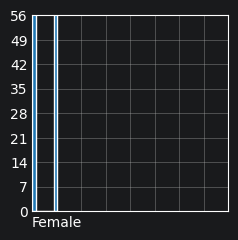

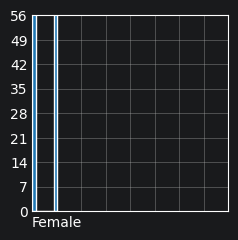

In [17]:
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots()

ax.hist(df_train['sex'], bins=8, linewidth=1, edgecolor="white")

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 56), yticks=np.linspace(0, 56, 9))

plt.show()


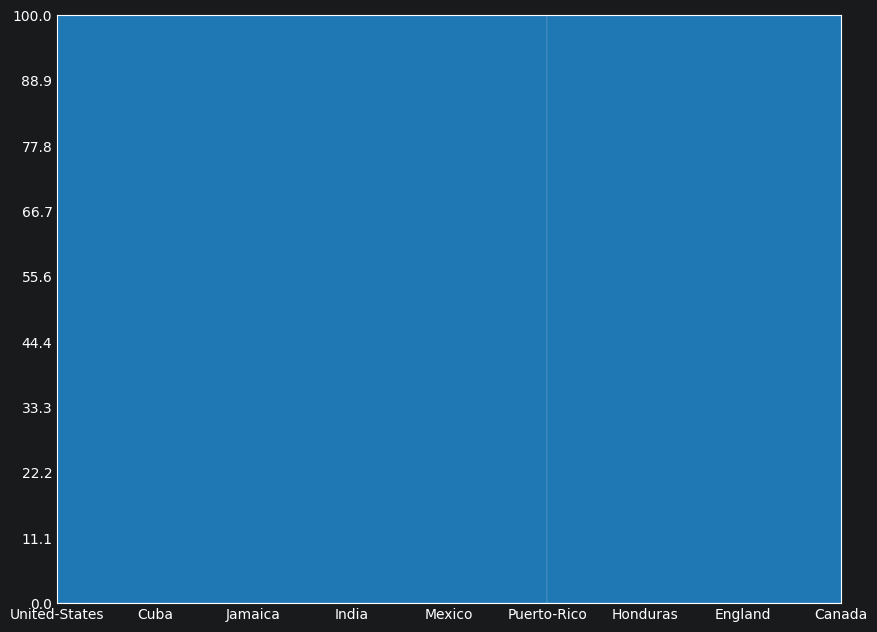

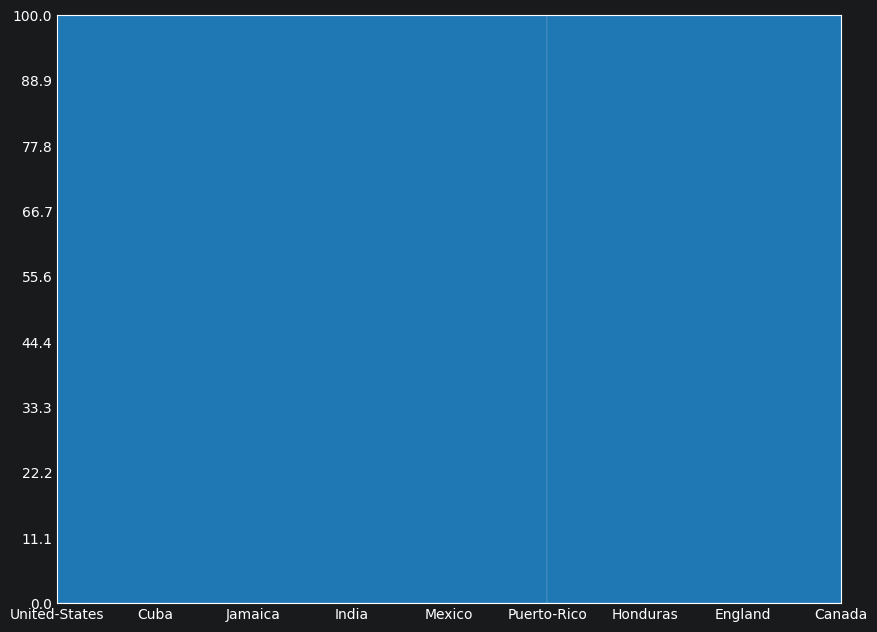

In [19]:
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(df_train['native-country'], bins=8, linewidth=.1, edgecolor="white")

ax.set(xlim=(0, 8), xticks=np.arange(0, 9),
       ylim=(0, 56), yticks=np.linspace(0, 100, 10))

plt.show()


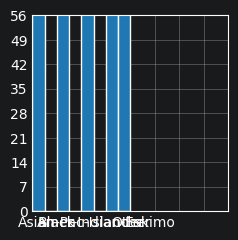

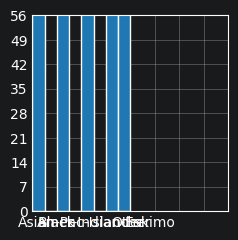

In [21]:
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots()

ax.hist(df_train['race'], bins=8, linewidth=1, edgecolor="white")

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 56), yticks=np.linspace(0, 56, 9))

plt.show()



# Drop unused columns


In [23]:
#education useless as we have education num column
drop_cols = ['work-fnl', 'education', 'sex', 'race', 'native-country', 'work-class']
df_train.drop(drop_cols, axis=1, inplace=True)
df_test.drop(drop_cols,  axis=1, inplace=True)
onehot_cols  = ["marital-status", "position", "relationship"]
cols_to_scale = ['capital-gain', 'capital-loss', 'age', 'hours-per-week']

KeyError: "['work-fnl', 'education', 'sex', 'race', 'native-country', 'work-class'] not found in axis"

In [ ]:
# Scale numeric columns
scaler = MinMaxScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test[cols_to_scale]  = scaler.transform(df_test[cols_to_scale])

In [ ]:
# One-hot encode categorical columns
train_size = len(df_train)
combined   = pd.concat([df_train, df_test], axis=0)
combined   = pd.get_dummies(combined, columns=onehot_cols).astype(int)
df_train   = combined.iloc[:train_size]
df_test    = combined.iloc[train_size:]

In [ ]:
X_train = df_train.drop(columns=[target])
y_train = df_train[target]
X_test  = df_test.drop(columns=[target])
y_test  = df_test[target]

In [ ]:
# ─── ✅ FIX: Apply SMOTE to balance the training set ─────────
print("⚖️  Balancing training data with SMOTE...")
print(f"   Before → {dict(zip(*np.unique(y_train, return_counts=True)))}")

In [ ]:
sm = SMOTE(random_state=42, sampling_strategy=0.5)  # Balance to 50% minority class
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

In [ ]:
# first vis
 print(f"   After  → {dict(zip(*np.unique(y_train_bal, return_counts=True)))}\n")

In [ ]:
# ─── Step 6: Train & Evaluate ────────────────────────────────
models = {
   "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.5),
   "Decision Tree": DecisionTreeClassifier(random_state=30, max_depth=10, min_samples_split=10, min_samples_leaf=4),
   "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15, min_samples_split=10),
   "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'),
   "SVM": SVC(random_state=42, kernel='rbf', C=0.8, gamma='scale'),
}

In [ ]:
trained_models = {name: model for name, model in models.items()}

In [ ]:
print("📊 Training Models...\n")
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    trained_models[name] = model

    print(f"{'='*50}")
    print(f"  {name}  |  Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp=ConfusionMatrixDisplay(cm,display_labels=le.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix for {name}")
    plt.show()

In [ ]:
MODEL_DIR = os.path.join(os.path.dirname(__file__), "models")
os.makedirs(MODEL_DIR, exist_ok=True)
#saving preproccesing file

In [ ]:
# showing correlation between features vs salray before correlation

df_train_corr_encoded = df_train.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(df_train_corr_encoded[['salary']], annot=True, cmap='coolwarm')

plt.show()

In [ ]:
# Save all trained models
for name, model in trained_models.items():
    joblib.dump(model, os.path.join(MODEL_DIR, f"{name.replace(' ', '_')}.pkl"))

In [ ]:
# Save scaler and label encoder
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(le,     os.path.join(MODEL_DIR, "label_encoder.pkl"))

In [ ]:
print("✅ Models saved successfully!")